# TDDE58 Lab
### Author: Sofia Knutas

In [74]:
# ---- Import required packets -----
import numpy as np
import matplotlib.pyplot as plt

# ---- Fixed parameters ----
SEED = 42           # set for reproducibility
N0 = 1e-9          # thermal noise power (mW)
alpha = 4           # path loss exponent
n_slots = int(1e5)  # number of simulated slots, should be large enough to reach a steady state

rng = np.random.default_rng(SEED)

#### Configure channel gains
The fading varaibles h1 and h2 are independent exponential random variables with mean one, redrawn each slot. Here, we are just testing it. 

mean h1: 1.0034967312171512
mean h2: 0.9946108718841656


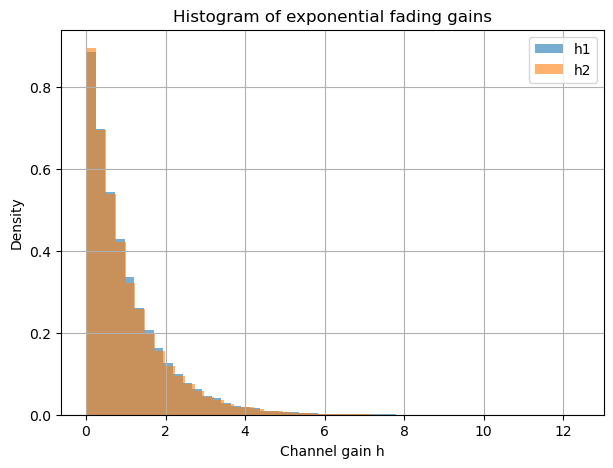

In [75]:
h1 = rng.exponential(1.0, n_slots)
h2 = rng.exponential(1.0, n_slots)

print("mean h1:", h1.mean())   # should be close to 1
print("mean h2:", h2.mean())   # should be close to 1

plt.figure(figsize=(7, 5))
plt.hist(h1, bins=50, alpha=0.6, label='h1', density=True)
plt.hist(h2, bins=50, alpha=0.6, label='h2', density=True)
plt.xlabel('Channel gain h')
plt.ylabel('Density')
plt.title('Histogram of exponential fading gains')
plt.legend()
plt.grid(True)
plt.show()

#### Set parameters for the simualtion


In [76]:
P_values = [1, 2, 4]       # mW
r_values = [200, 400]      # m
gamma_values = [0.2, 1, 3]


#### Simulate the different protocols as functions

In [77]:
def simulate_tdma(P, r, gamma, n_slots, rng):
    """TDMA: user 1 gets odd slots, user 2 gets even slots. There can be no interference."""
    h1 = rng.exponential(1.0, n_slots)
    h2 = rng.exponential(1.0, n_slots)

    snr1 = P * h1 * r**(-alpha) / N0
    snr2 = P * h2 * r**(-alpha) / N0

    user1_slots = np.arange(n_slots) % 2 == 0
    user2_slots = ~user1_slots

    success1 = np.sum(snr1[user1_slots] > gamma)
    success2 = np.sum(snr2[user2_slots] > gamma)

    throughput = (success1 + success2) / n_slots
    return throughput


def simulate_aloha(P, r, gamma, n_slots, rng):
    """Slotted ALOHA with q=1, so both users transmit every slot."""
    h1 = rng.exponential(1.0, n_slots)
    h2 = rng.exponential(1.0, n_slots)

    rx1 = P * h1 * r**(-alpha)
    rx2 = P * h2 * r**(-alpha)

    sinr1 = rx1 / (rx2 + N0)
    sinr2 = rx2 / (rx1 + N0)

    success1 = np.sum(sinr1 > gamma)
    success2 = np.sum(sinr2 > gamma)

    throughput = (success1 + success2) / n_slots
    return throughput

#### Create the plots
Outer loops goes over the gamma values, and here the three figures are created respectively. 
Then we have an inner loop running over the r, radius, from where we can actually then get the four curves. 
Lastly, we also run over the P values in the most inner loop. 

gamma=0.2, r=200 m
  TDMA:  ['7.2746e-01', '8.5163e-01', '9.2337e-01']
  ALOHA: ['1.2108e+00', '1.4198e+00', '1.5414e+00']
gamma=0.2, r=400 m
  TDMA:  ['5.7000e-03', '7.6830e-02', '2.7828e-01']
  ALOHA: ['9.8700e-03', '1.2824e-01', '4.6258e-01']


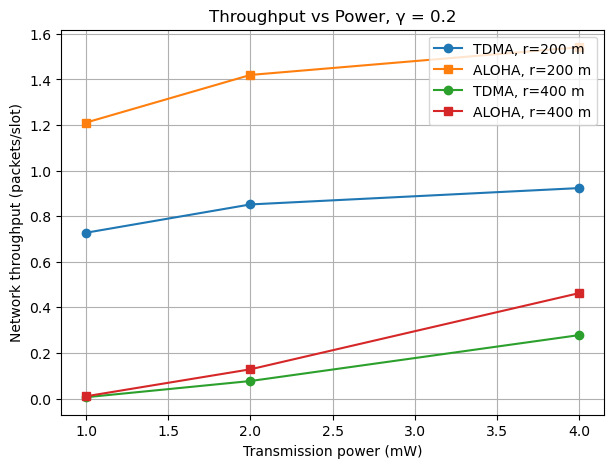

gamma=1, r=200 m
  TDMA:  ['2.0231e-01', '4.4812e-01', '6.6903e-01']
  ALOHA: ['2.0185e-01', '4.4895e-01', '6.7190e-01']
gamma=1, r=400 m
  TDMA:  ['0.0000e+00', '0.0000e+00', '1.6400e-03']
  ALOHA: ['0.0000e+00', '0.0000e+00', '1.4500e-03']


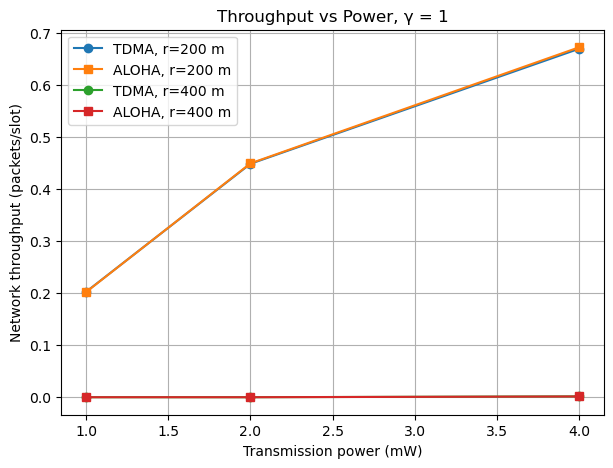

gamma=3, r=200 m
  TDMA:  ['8.2500e-03', '9.0330e-02', '3.0267e-01']
  ALOHA: ['4.3200e-03', '4.5350e-02', '1.5305e-01']
gamma=3, r=400 m
  TDMA:  ['0.0000e+00', '0.0000e+00', '0.0000e+00']
  ALOHA: ['0.0000e+00', '0.0000e+00', '0.0000e+00']


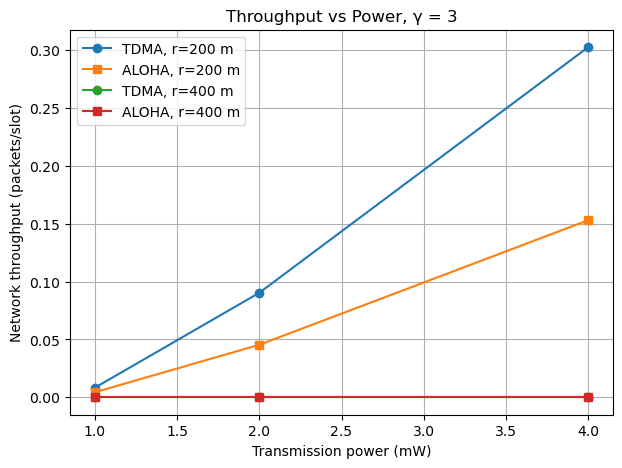

In [78]:
for gamma in gamma_values:
    plt.figure(figsize=(7, 5))

    for r in r_values:
        tdma_throughput = [simulate_tdma(P, r, gamma, n_slots, rng) for P in P_values]
        aloha_throughput = [simulate_aloha(P, r, gamma, n_slots, rng) for P in P_values]

        print(f"gamma={gamma}, r={r} m")
        print(f"  TDMA:  {[f'{v:.4e}' for v in tdma_throughput]}")
        print(f"  ALOHA: {[f'{v:.4e}' for v in aloha_throughput]}")

        plt.plot(P_values, tdma_throughput, marker='o', label=f'TDMA, r={r} m')
        plt.plot(P_values, aloha_throughput, marker='s', label=f'ALOHA, r={r} m')

    plt.xlabel('Transmission power (mW)')
    plt.ylabel('Network throughput (packets/slot)')
    plt.title(f'Throughput vs Power, γ = {gamma}')
    plt.legend()
    plt.grid(True)
    plt.show()

#### Discussion on the figures
1. Figure 1 (γ = 0.2): Aloha performs better in both 200m and 400m, even though the difference is bigger on the shorter distance. When the radius is 400m both have a hard time to have barely any throughput when the transmission power is low.

2. Figure 2 (γ = 1): At r=200m, TDMA and ALOHA are nearly identical at every power level. At r=400m, both crash to near-zero, with only P=4mW producing any successes at all, and TDMA performing out ALOHA very slightly there.
At γ=0.2, ALOHA had a clear lead over TDMA and just increasing γ=1, that lead is gone. Here we can conclude that ALOHA gets "two attempts per slot," but pays an interference penalty. This results therefore shows that the interference is more sensitive to γ increasing.
  

3. Figure 3 (γ = 3): At r=200m, TDMA clearly outperforms ALOHA now. However, at r=400m, every power level tested gives only zeros for both protocols. The signal is to weak to reach up to γ in all probably all cases.
ALOHA's relative performance dropa a lot between γ=1 and γ=3, this is because tripling γ also triples the size of the interference penalty. This then means that the same interference is being weighed against an increasingly demanding standard and that's why ALOHA doesn't just lose a little more between γ=1 and γ=3, since the fixed 2×-attempts benefit stays flat while the interference penalty keeps scaling up.

#### Key takeaways: 
- The interference is a fixed presence, but its impact grows with γ. At low γ, that interference term almost does not matter. So at low γ, interference is technically worse than a world with no interference at all, but not bad enough to erase ALOHA's advantage over TDMA since it always sends two packets instead of one. As γ rises, that same interference term costs more and more, until eventually it costs enough to cancel out the 2× benefit entirely, which is when TDMA starts winning instead.

- Since h has mean 1, the avarage SNR at a given P and r is:
$$\overline{SNR} = \frac{P \cdot r^{-4}}{N_0}$$

At r=400m: $r^{-4} = 400^{-4} \approx 3.91 \times 10^{-11}$

Even at the highest tested power (P=4mW) the avarage slot isn't close to succeeding; a packet only gets through when the random channel gain h happens to be very much larger than usual. And because h is exponential with mean 1, the probability of drawing a value that large is unlikely and rare.
  